In [ ]:
import numpy as np
from scipy.io import loadmat

"""
This cell is code specific to this dataset, uses event markers to extract epochs and align labels.
Dataset is for classifying ErrPs elicted by participants observing a cursor move toward or away from an onscreen target.
Downloadable here under dataset #22: https://bnci-horizon-2020.eu/database/data-sets
Paper is "Learning From EEG Error-Related Potentials in Noninvasive Brain-Computer Interfaces (2010)".
"""

# --- configurable epoch window (seconds) ---
PRE_S  = 0.2
POST_S = 0.8

# Event codes (dataset description)
CORRECT_CODES = {5, 10}
ERROR_CODES   = {6, 9}
KEEP_CODES    = CORRECT_CODES | ERROR_CODES

def _unwrap(x):
    """Unwrap MATLAB cell/1x1 object arrays to the underlying value."""
    while isinstance(x, np.ndarray) and x.dtype == object and x.size == 1:
        x = x.flat[0]
    return x

def _cell_to_list(cell):
    """Convert MATLAB cell array to Python list, unwrapping each element."""
    cell = _unwrap(cell)
    if isinstance(cell, np.ndarray) and cell.dtype == object:
        return [_unwrap(el) for el in cell.flat]
    # Already a list-like
    if isinstance(cell, (list, tuple)):
        return [ _unwrap(el) for el in cell ]
    return [cell]

def _get_struct_field(struct, name):
    """
    Robustly get 'name' from a MATLAB struct loaded via scipy:
    - attribute (struct.eeg)
    - numpy record/void with dtype.names (struct['eeg'])
    - plain dict
    Returns the *unwrapped* field value.
    """
    s = _unwrap(struct)

    # Attribute style (scipy mat_struct when struct_as_record=False)
    if hasattr(s, name):
        return _unwrap(getattr(s, name))

    # numpy void / record array style
    if isinstance(s, np.void) and s.dtype.names and (name in s.dtype.names):
        return _unwrap(s[name])
    if isinstance(s, np.ndarray) and s.dtype.names and (name in s.dtype.names):
        return _unwrap(s[name])

    # dict-like
    if isinstance(s, dict) and name in s:
        return _unwrap(s[name])

    # If it's an ndarray of structs, try the first element
    if isinstance(s, np.ndarray) and s.size > 0:
        first = _unwrap(s.flat[0])
        return _get_struct_field(first, name)

    raise KeyError(f"Field '{name}' not found on struct with type {type(s)}")

def _maybe_squeeze_vector(x):
    """Squeeze arrays and return 1D vectors where appropriate."""
    arr = np.array(x)
    if arr.ndim > 2:
        arr = np.squeeze(arr)
    if arr.ndim == 2 and 1 in arr.shape:
        arr = arr.reshape(-1)
    return arr

def _extract_event_pos_typ(event_struct):
    """Return (pos, typ) as 1D integer arrays, fix POS/TYP swaps if needed."""
    POS_raw = _get_struct_field(event_struct, 'POS')
    TYP_raw = _get_struct_field(event_struct, 'TYP')

    POS = _maybe_squeeze_vector(POS_raw).astype(int)
    TYP = _maybe_squeeze_vector(TYP_raw).astype(int)

    if POS.size and TYP.size:
        if POS.max() <= 64 and TYP.max() > 1000:  # looks swapped
            POS, TYP = TYP, POS

    return POS, TYP

def load_errp_eeg(mat_path):
    """
    Returns:
      X: (num_samples, num_channels, num_timesteps)
      y: (num_samples,), 1=correct, 0=error
    """
    m = loadmat(mat_path, squeeze_me=False, struct_as_record=False)

    # Some files use 'run', others might use 'Runs' or similar—try common keys:
    for k in ('run', 'runs', 'Run', 'Runs'):
        if k in m:
            run_cell = m[k]
            break
    else:
        raise KeyError(f"Could not find a 'run' cell/array in {list(m.keys())}")

    runs = _cell_to_list(run_cell)

    X_segments, y_labels = [], []

    for run_idx, run_struct in enumerate(runs, start=1):
        # Access fields robustly
        eeg    = _get_struct_field(run_struct, 'eeg')          # (T x C) expected
        header = _get_struct_field(run_struct, 'header')

        # Sampling rate
        fs = int(np.array(_unwrap(_get_struct_field(header, 'SampleRate'))).squeeze())
        # Epoch sizes
        pre_samp  = int(round(PRE_S  * fs))
        post_samp = int(round(POST_S * fs))
        win_len   = pre_samp + post_samp

        # Events
        event = _get_struct_field(header, 'EVENT')
        pos, typ = _extract_event_pos_typ(event)

        # Ensure EEG shape (T, C)
        eeg = np.array(eeg)
        if eeg.ndim > 2:
            eeg = np.squeeze(eeg)
        if eeg.ndim != 2:
            raise ValueError(f"Unexpected EEG shape for run {run_idx}: {eeg.shape}")
        T, C = eeg.shape

        # Epoching
        for p, t in zip(pos, typ):
            if int(t) not in KEEP_CODES:
                continue
            start, end = p - pre_samp, p + post_samp
            if start < 0 or end > T:
                continue
            seg = eeg[start:end, :]             # (win_len, C)
            if seg.shape[0] != win_len:         # guard against off-by-one
                continue
            X_segments.append(seg.T)            # -> (C, win_len)
            y_labels.append(1 if int(t) in CORRECT_CODES else 0)

    if not X_segments:
        raise RuntimeError(
            "No valid epochs found. Try adjusting PRE_S/POST_S or verify event codes."
        )

    X = np.stack(X_segments, axis=0)  # (N, C, T)
    y = np.array(y_labels, dtype=int) # (N,)
    return X, y



In [3]:
X, y = load_errp_eeg("data/Subject01_s1.mat")
print(X.shape, y.shape)

(489, 64, 512) (489,)


In [5]:
import numpy as np
unique_labels, counts = np.unique(y,return_counts=True)
print("Dataset label counts:")
print(np.asarray((unique_labels, counts)).T)

Dataset label counts:
[[  0 118]
 [  1 371]]


In [6]:
import numpy as np
from scipy import signal

def _butter_bandpass(low, high, fs, order=4):
    nyq = 0.5 * fs
    low = low / nyq if low is not None else None
    high = high / nyq if high is not None else None
    if low and high:
        b, a = signal.butter(order, [low, high], btype="bandpass")
    elif low:
        b, a = signal.butter(order, low, btype="highpass")
    elif high:
        b, a = signal.butter(order, high, btype="lowpass")
    else:
        raise ValueError("At least one of low or high must be set.")
    return b, a

def _apply_filtfilt_3d(x, b, a):
    # x: (N, C, T); run along last axis
    N, C, T = x.shape
    y = np.empty_like(x, dtype=np.float64)
    padlen = min(3 * max(len(a), len(b)), max(1, T - 1))
    for i in range(N):
        y[i] = signal.filtfilt(b, a, x[i], axis=-1, padlen=padlen)
    return y

def _apply_notch(x, fs, f0, q=30.0, max_harmonics=None):
    if f0 is None or f0 <= 0:
        return x
    nyq = 0.5 * fs
    max_h = int(nyq // f0) if max_harmonics is None else max_harmonics
    y = x
    for h in range(1, max_h + 1):
        f = h * f0
        if f >= nyq - 1e-6:
            break
        b, a = signal.iirnotch(w0=f/nyq, Q=q)
        N, C, T = y.shape
        tmp = np.empty_like(y, dtype=np.float64)
        padlen = min(3 * max(len(a), len(b)), max(1, T - 1))
        for i in range(N):
            tmp[i] = signal.filtfilt(b, a, y[i], axis=-1, padlen=padlen)
        y = tmp
    return y

def _common_average_reference(x):
    return x - x.mean(axis=1, keepdims=True)

def _detect_bad_channels_variance(x, z_thresh_high=3.5, z_thresh_low=-3.5):
    C = x.shape[1]
    flat = np.reshape(np.transpose(x, (1,0,2)), (C, -1))
    ch_var = np.var(flat, axis=1)
    z = (ch_var - ch_var.mean()) / (ch_var.std() + 1e-12)
    bad = np.where((z > z_thresh_high) | (z < z_thresh_low) | (ch_var < 1e-12))[0]
    return bad, ch_var

def _repair_bad_channels(x, bad_idx):
    if bad_idx.size == 0:
        return x
    N, C, T = x.shape
    good = np.setdiff1d(np.arange(C), bad_idx)
    y = x.copy()
    if good.size == 0:
        return np.zeros_like(x)
    median_good = np.median(x[:, good, :], axis=1, keepdims=True)  # (N,1,T)
    y[:, bad_idx, :] = np.repeat(median_good, repeats=bad_idx.size, axis=1)
    return y

def _per_channel_zscore(x):
    mean = x.mean(axis=-1, keepdims=True)
    std = x.std(axis=-1, keepdims=True)
    return (x - mean) / (std + 1e-12)

def clean_eeg(
    data,
    sfreq,
    *,
    line_freq=60.0,         # set 50.0 for EU mains
    notch_Q=30.0,
    band=(1.0, 40.0),       # set (None, H) or (L, None) if needed
    filter_order=4,
    do_car=True,
    var_z_high=3.5,
    var_z_low=-3.5,
    zscore_each_sample=True,
):
    """
    Clean EEG shaped (N, C, T) WITHOUT dropping samples or resampling.
    Returns: cleaned_data (same shape).
    """
    x = np.asarray(data, dtype=np.float64)
    assert x.ndim == 3, "Input must be (num_samples, num_channels, num_timesteps)"
    N0, C0, T0 = x.shape
    notes = {}

    # Detrend
    x = signal.detrend(x, axis=-1, type="linear")

    # Notch line noise (+ harmonics)
    x = _apply_notch(x, fs=sfreq, f0=line_freq, q=notch_Q)

    # Band-pass
    if band is not None:
        b, a = _butter_bandpass(band[0], band[1], fs=sfreq, order=filter_order)
        x = _apply_filtfilt_3d(x, b, a)

    # CAR
    if do_car:
        x = _common_average_reference(x)

    # Bad-channel detect + repair (median of good channels)
    bad_ch, ch_var = _detect_bad_channels_variance(x, z_thresh_high=var_z_high, z_thresh_low=var_z_low)
    notes["num_bad_channels"] = int(bad_ch.size)
    notes["bad_channels_idx"] = bad_ch.copy()
    x = _repair_bad_channels(x, bad_ch)




    # Optional per-sample z-score (does not change shape)
    if zscore_each_sample:
        x = _per_channel_zscore(x)
        
    return x



In [7]:
# -----------------------
rng = np.random.default_rng(0)
cleaned = clean_eeg(
    X, sfreq=256.0, line_freq=60.0, band=(1.0, 40.0)
)

In [8]:
from classify.classify import classify_torch
from classify import EEGNet
from sklearn.model_selection import LeaveOneGroupOut

### Kwargs are initialization arguments for the pytorch model class passed into classify_torch ###
kwargs = {'num_electrodes':cleaned.shape[1], 'chunk_size': cleaned.shape[-1],'num_classes':2}

### classify_torch performs cross validation, evaluating each fold on a held out set and averaging performance metrics across all folds ###
metrics_dict = classify_torch(cleaned,y,EEGNet,kwargs=kwargs,num_epochs=40,bayesian=True,return_preds=True)
    

Device: cuda:0
Epoch [1/40], Loss: 1.0865
Epoch [2/40], Loss: 0.9680
Epoch [3/40], Loss: 0.8788
Epoch [4/40], Loss: 0.8734
Epoch [5/40], Loss: 0.7978
Epoch [6/40], Loss: 0.7661
Epoch [7/40], Loss: 0.7793
Epoch [8/40], Loss: 0.7269
Epoch [9/40], Loss: 0.7111
Epoch [10/40], Loss: 0.6616
Epoch [11/40], Loss: 0.6583
Epoch [12/40], Loss: 0.6643
Epoch [13/40], Loss: 0.6571
Epoch [14/40], Loss: 0.6598
Epoch [15/40], Loss: 0.6497
Epoch [16/40], Loss: 0.6644
Epoch [17/40], Loss: 0.5760
Epoch [18/40], Loss: 0.5919
Epoch [19/40], Loss: 0.6452
Epoch [20/40], Loss: 0.5738
Epoch [21/40], Loss: 0.6295
Epoch [22/40], Loss: 0.5695
Epoch [23/40], Loss: 0.5771
Epoch [24/40], Loss: 0.5515
Epoch [25/40], Loss: 0.5735
Epoch [26/40], Loss: 0.5713
Epoch [27/40], Loss: 0.5400
Epoch [28/40], Loss: 0.5297
Epoch [29/40], Loss: 0.5182
Epoch [30/40], Loss: 0.5380
Epoch [31/40], Loss: 0.5364
Epoch [32/40], Loss: 0.5059
Epoch [33/40], Loss: 0.5140
Epoch [34/40], Loss: 0.5123
Epoch [35/40], Loss: 0.5180
Epoch [36/40],

In [9]:
print(metrics_dict)

{'mean_accuracy': 0.8609375, 'best_accuracy': 1.0, 'worst_accuracy': 0.5, 'mean_precision': 0.8406339281627536, 'best_precision': 1.0, 'worst_precision': 0.25, 'mean_recall': 0.8609375, 'best_recall': 1.0, 'worst_recall': 0.5, 'mean_f1': 0.8419806130450513, 'best_f1': 1.0, 'worst_f1': 0.3333333333333333, 'mean_difference': 0.12065439672801637, 'median_difference': 0.0, 'predictions': [(1, 1), (1, 1), (1, 1), (1, 1), (0, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (0, 1), (1, 1), (1, 1), (1, 1), (0, 0), (1, 0), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (0, 0), (1, 1), (1, 0), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (0, 0), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 0), (1, 1), (1, 1), (1, 0), (1, 0), (1, 1), (1, 1), (0, 0), (0, 1), (1, 1), (1, 1), (0, 0), (1, 1), (1, 1), (1, 0), (0, 1), (1, 1), (1, 1), (1, 1), (1, 0), (1, 1), (1, 1), (1, 1), (0, 0), (1, 1), (1, 1), (1, 1), (1, 0), (1, 1), (0, 0), (1, 1), (1, 1), (1, 1), (1, 

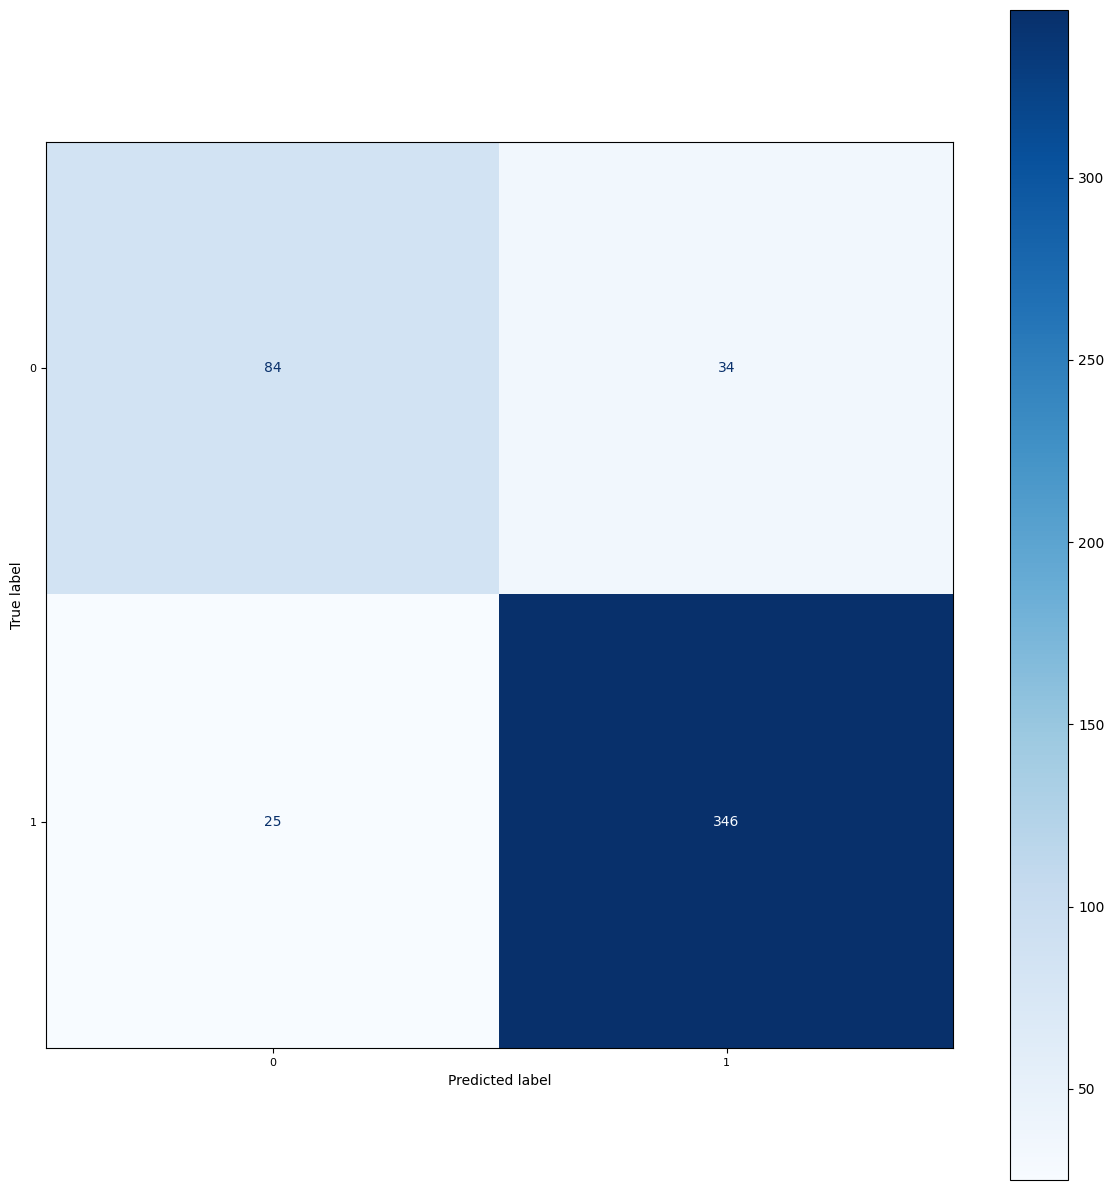

In [10]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

preds = [p for p, _ in metrics_dict["predictions"]]
real = [p for _, p in metrics_dict["predictions"]]

class_names = np.unique(real)
cm = confusion_matrix(real, preds, labels=class_names)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(ax=ax, cmap="Blues", colorbar=True)

plt.xticks(rotation=0, ha="center", fontsize=8)
plt.yticks(rotation=0, ha="right", fontsize=8)

plt.tight_layout()
plt.show()